# Pandas

Pandas is an open-source software library built on Python for data analysis and data manipulation.  It is used for working with data sets and has functions for analyzing, cleaning, exploring, and manipulating data - namely Data wrangling.

The name "Pandas" has a reference to both "Panel Data", and "Python Data Analysis" and was created by Wes McKinney in 2008.

## Power of Pandas
- __Discovering:__ This is the first step to familiarize yourself with your data and get a better feel for how you will use it. To get familiar with the data, you must have the appropriate context to easily consume and analyze it. Data definitions, lineages, business rules, samples, types and domains all help accelerate the end users’ understanding and ability to act quickly on the data.


- __Structuring:__ A lot of the raw data may not be useful. To cleanse and join massive data sets (hundreds of thousands of rows), standardizing and conforming capabilities are required to simplify and consolidate future steps. This includes formatting in a standard way, as well as organizing fields for quick analysis (i.e., qualitative verses quantitative values).


- __Cleaning:__ This step ensures the completeness of the data through profiling results to identify patterns in the data, along with errors, such as missing or incomplete values, that need to be addressed. What you do in this phase informs every activity that comes afterward. Other examples are removing outliers that will skew results and formatting null values.
- __Enriching:__ During this step, data analysts will determine whether adding data sets would benefit their analysis. For example, adding new fields, aggregating existing ones, or bringing lookup tables to translate technical jargon to business terminology.


- __Validating:__ This step refers to the process of verifying that your data is both consistent and of high quality. Data validation is typically done by checking whether the datasets are accurate against the source and if attributes are normally distributed.


- __Publishing:__ When the data is fit for use, it can be shared and easily accessed by the appropriate data consumers to take actionable insights, build upon initial goals and identify additional opportunities to collaborate upon.


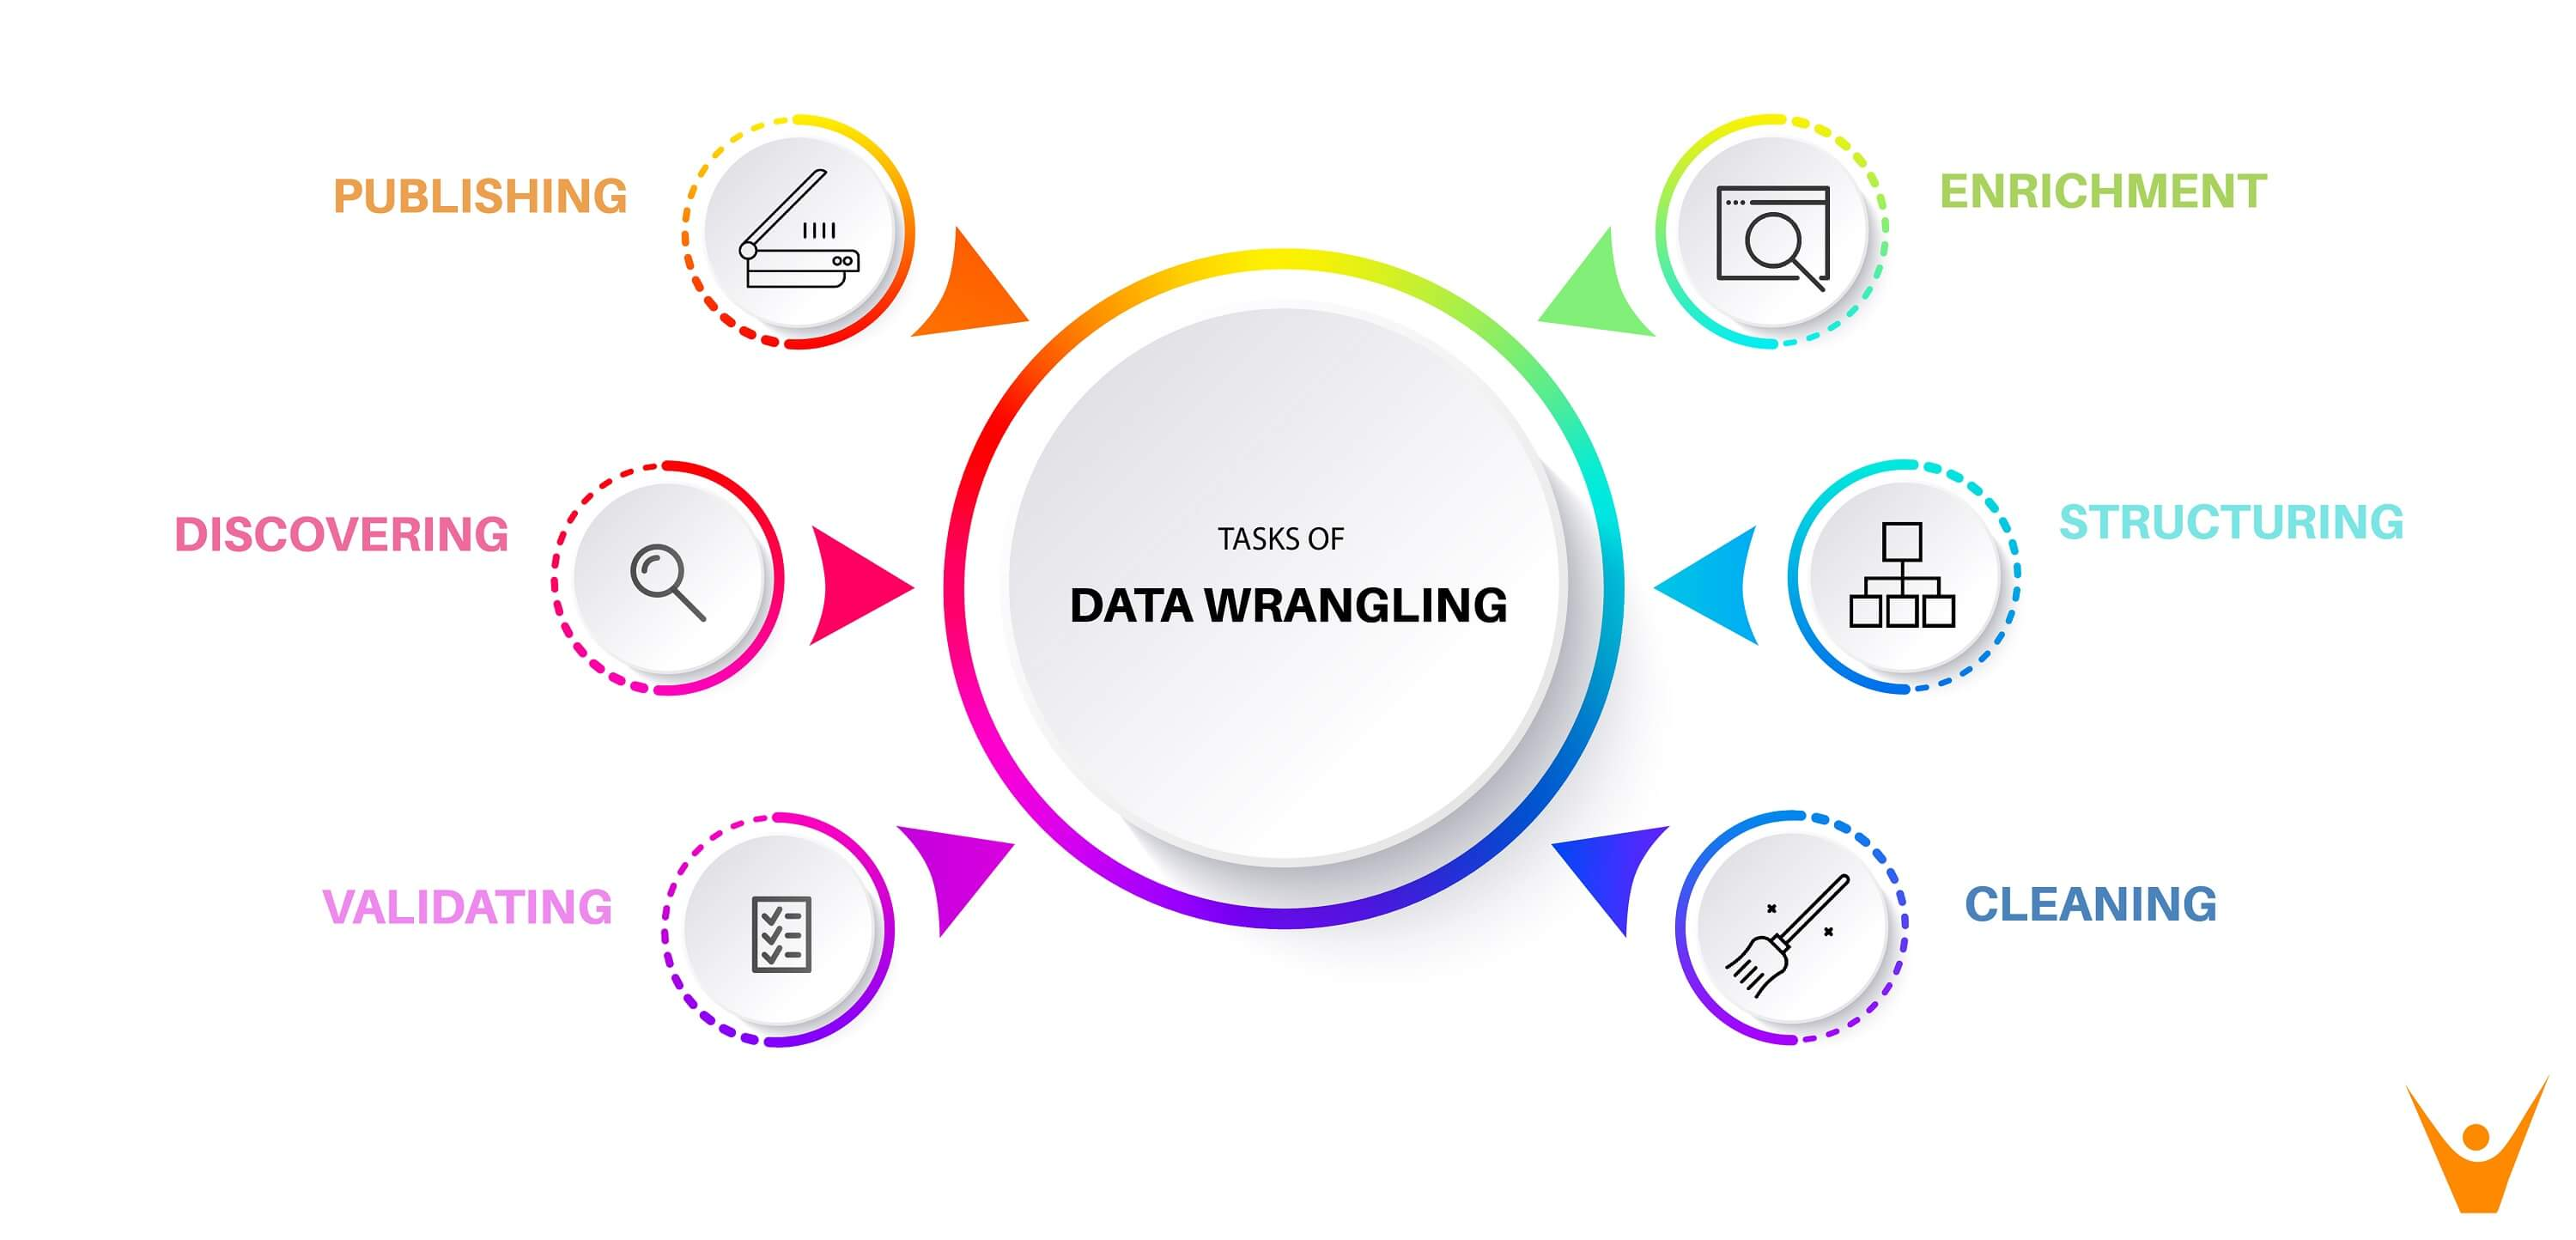

In [1]:
import pandas as pd

# Syntax

In [6]:
df = pd.DataFrame({"a" : [4 ,5, 6], 
                   "b" : [7, 8, 9], 
                   "c" : [10, 11, 12]},    
                  index = [1, 2, 3])
df

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12


In [7]:
df1 = pd.DataFrame([[4, 7, 10],
                    [5, 8, 11],
                    [6, 9, 12]], 
                   index=[1, 2, 3], 
                   columns=['a', 'b', 'c'])

df1

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12


In [8]:
df2 = pd.DataFrame({"a" : [4 ,5, 6], 
                    "b" : [7, 8, 9], 
                    "c" : [10, 11, 12]},    
                   index = pd.MultiIndex.from_tuples([('d',1),
                                                      ('d',2),
                                                      ('e',2)],
                                                     names=['n','v']))
df2

a  b   c
n v          
d 1  4  7  10
  2  5  8  11
e 2  6  9  12

# Method Chaining
Most pandas methods return a DataFrame so that another pandas method can be applied to the result.  This improves readability of code.

In [3]:
df = (pd.melt(df)
      .rename(columns={'variable' : 'var',  
                       'value' : 'val'})
      .query('val >= 200')
     )

In [4]:
df

,var,val


# Sammarize Data

Basic descriptive statistics for each column (or GroupBy) pandas provides a large set of summary functions that operate on  different kinds of pandas objects (DataFrame columns, Series,  GroupBy, Expanding and Rolling (see below)) and produce single  values for each of the groups. When applied to a DataFrame, the  result is returned as a pandas Series for each column. 

Examples: 

- __df['w'].value_counts():__ Count number of rows with each unique value of variable


- __len(df):__ # of rows in DataFrame.


- __df['w'].nunique():__ # of distinct values in a column.


- __df.describe():__ Basic descriptive statistics for each column (or GroupBy)


- __sum():__ Sum values of each object.


- __count():__ Count non-NA/null values of each object.


- __median():__ Median value of each object.


- __quantile([0.25,0.75]):__ Quantiles of each object.


- __apply(function):__ Apply function to each object.


- __min():__ Minimum value in each object.


- __max():__ Maximum value in each object.


- __mean():__ Mean value of each object.


- __var():__ Variance of each object.


- __std():__ Standard deviation of each object.



In [9]:
len(df)

3

In [10]:
df.describe()

,a,b,c
count,3.0,3.0,3.0
mean,5.0,8.0,11.0
std,1.0,1.0,1.0
min,4.0,7.0,10.0
25%,4.5,7.5,10.5
50%,5.0,8.0,11.0
75%,5.5,8.5,11.5
max,6.0,9.0,12.0


# Handling Missing Data

- __df.isna(), df.isna().sum(), df.isnull(), df.isnaull().sum()__


- __df.dropna():__ Drop rows with any column having NA/null data.


- __df.fillna(value):__ Replace all NA/null data with value.

In [11]:
df.isna().sum()

a    0
b    0
c    0
dtype: int64

# Make New Columns

- __df.assign(Area=lambda df: df.Length*df.Height):__ Compute and append one or more new columns.


- __df['Volume'] = df.Length*df.Height*df.Depth:__ Add single column.


- __pd.qcut(df.col, n, labels=False):__ Bin column into n buckets, in equal number of data (e.g.: bin = n = 4 ~ [ < Q1, < Q2, < Q3, < max_val]. With Q1, Q2, Q3 refereing to 1st, 2nd, and 3rd quartile.


- __pd.cut(df.col, n, labels=False):__ Bin column into n buckets, and it guarantes that intervals are equal (it ignores amount of data in each buckets, only 

Pandas provides a large set of vector functions that operate on all columns of a DataFrame or a single selected column (a pandas Series). These functions produce vectors of values for each of the columns, or a single Series for the individual Series. 


Examples:

- __max(axis=1):__ Element-wise max.


- __clip(lower=-10,upper=10):__ Trim values at input thresholds


- __min(axis=1):__ Element-wise min.


- __abs():__ Absolute value.




In [12]:
pd.qcut(df.a, 4)

1    (3.999, 4.5]
2      (4.5, 5.0]
3      (5.5, 6.0]
Name: a, dtype: category
Categories (4, interval[float64, right]): [(3.999, 4.5] < (4.5, 5.0] < (5.0, 5.5] < (5.5, 6.0]]

In [14]:
pd.qcut(df.a, 4, labels=[1,2,3,4])

1    1
2    2
3    4
Name: a, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]

# Group Data

- __df.groupby(by="col"):__ Return a GroupBy object, grouped by values in column named "col".


- __df.groupby(level="ind"):__ Return a GroupBy object, grouped by values in index level named "ind".


All of the summary functions listed above can be applied to a group. 
Additional GroupBy functions:


- __agg(function):__ Aggregate group using function.


- __size():__ Size of each group.


- __shift(-1):__ Copy with values shifted by 1.


- __shift(1):__ Copy with values lagged by 1.


- __rank(method='dense'):__ Ranks with no gaps.


- __rank(method='min'):__ Ranks. Ties get min rank.



- __rank(pct=True):__ Ranks rescaled to interval [0, 1].


- __rank(method='first'):__ Ranks. Ties go to first value.


- __cumsum():__ Cumulative sum.


- __cummax():__ Cumulative max.


- __cummin():__ Cumulative min.


- __cumprod():__ Cumulative product.



# Tidy Data

# Reshape Data
Change the layout of a data set


- __pd.melt(df):__ Gather columns into rows.


- __df.pivot(columns='var', values='val'):__ Spread rows into columns.


- __pd.concat([df1,df2]):__  Append rows of DataFrames


- __df.sort_values('mpg'):__ Order rows by values of a column (low to high).


- __df.sort_values('mpg',ascending=False):__ Order rows by values of a column (high to low).


- __df.rename(columns = {'y':'year'}):__ Rename the columns of a DataFrame


- __pd.concat([df1,df2], axis=1):__ Append columns of DataFrames


- __df.sort_index():__ Sort the index of a DataFrame


- __df.reset_index():__ Reset index of DataFrame to row numbers, moving index to columns.


- __df.drop(columns=['Length','Height']):__ Drop columns from DataFrame



In [18]:
df

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12


In [26]:
data = pd.melt(df)
data

,variable,value
0,a,4
1,a,5
2,a,6
3,b,7
4,b,8
5,b,9
6,c,10
7,c,11
8,c,12


In [28]:
data.pivot(columns='variable', values='value')

variable,a,b,c
0,4.0,NaN,NaN
1,5.0,NaN,NaN
2,6.0,NaN,NaN
3,NaN,7.0,NaN
4,NaN,8.0,NaN
5,NaN,9.0,NaN
6,NaN,NaN,10.0
7,NaN,NaN,11.0
8,NaN,NaN,12.0




# Subset Observations


- __df.sample(n=10):__ Randomly select n rows.


- __df.iloc[10:20]:__ Select rows by position.


- __df.nlargest(n, 'value'):__ Select and order top n entries.


- __df.nsmallest(n, 'value'):__ Select and order bottom n entries.


- __df.sample(frac=0.5):__ Randomly select fraction of rows. 



- __f[df.Length > 7]:__ Extract rows that meet logical criteria.


- __df.drop_duplicates():__ Remove duplicate rows (only considers columns).



- __df.head(n):__ Select first n rows.


- __df.tail(n):__ Select last n rows.





In [29]:
df.sample(frac=.5)

,a,b,c
2,5,8,11
1,4,7,10


# Subset Variables (Columns)


- __df[['width','length','species']]:__ Select multiple columns with specific names.



- __df['width']__  or __df.width:__ Select single column with specific name.



- __df.filter(regex='regex'):__ Select columns whose name matches regular expression regex.



- __df.loc[:,'x2':'x4']:__ Select all columns between x2 and x4 (inclusive).



- __df.iloc[:,[1,2,5]]:__ Select columns in positions 1, 2 and 5 (first column is 0).



- __df.loc[df['a'] > 10, ['a','c']]:__ Select rows meeting logical condition, and only the specific columns .

# Windows
- __df.expanding():__ Return an Expanding object allowing summary functions to be applied cumulatively.


- __df.rolling(n):__ Return a Rolling object allowing summary functions to be applied to windows of length n.



In [47]:
df.rolling(2)

Rolling [window=2,center=False,axis=0,method=single]

# Combin Data Sets


- __pd.merge(adf, bdf, how='left', on='x1'):__ Join matching rows from bdf to adf.


- __pd.merge(adf, bdf, how='right', on='x1'):__ Join matching rows from adf to bdf.


- __pd.merge(adf, bdf, how='inner', on='x1'):__ Join data. Retain only rows in both sets.


- __pd.merge(adf, bdf, how='outer', on='x1'):__ Join data. Retain all values, all rows.




Filtering Joins


- __adf[adf.x1.isin(bdf.x1)]:__ All rows in adf that have a match in bdf.


- __adf[~adf.x1.isin(bdf.x1)]:__ All rows in adf that do not have a match in bdf.

- __pd.merge(ydf, zdf):__ Rows that appear in both ydf and zdf (Intersection).



- __pd.merge(ydf, zdf, how='outer'):__
Rows that appear in either or both ydf and zdf (Union).



- __pd.merge(ydf, zdf, how='outer', indicator=True).query('_merge == "left_only"').drop(columns=['_merge']):__
Rows that appear in ydf but not zdf (Setdiff).

In [34]:
adf = pd.DataFrame([['A', 1],
                   ['B', 2],
                   ['C', 3]], columns= ['x1', 'x2'])


bdf = pd.DataFrame([['A',  'T'],
                    ['B',  'F'],
                    ['D',  'T']], columns=['x1', 'x2'])               

In [35]:
pd.merge(adf, bdf, how='left', on='x1')

,x1,x2_x,x2_y
0,A,1,T
1,B,2,F
2,C,3,NaN


In [36]:
pd.merge(adf, bdf, how='inner', on='x1')

,x1,x2_x,x2_y
0,A,1,T
1,B,2,F


In [38]:
ydf = pd.DataFrame(columns= ['x1', 'x2'],
             data = [[ 'A',  1],
                     [ 'B',  2],
                     [ 'C',  3]])


zdf = pd.DataFrame(columns= ['x1', 'x2'],
             data = [[ 'B',  3],
                     [ 'C',  4],
                     [ 'D',  5]])

In [39]:
pd.merge(ydf, zdf)

,x1,x2


In [40]:
pd.merge(ydf, zdf, how='outer')

,x1,x2
0,A,1
1,B,2
2,B,3
3,C,3
4,C,4
5,D,5


In [46]:

pd.merge(ydf, zdf, how='outer', 
         indicator=True).query('_merge == "left_only"').drop(columns=['_merge'])

,x1,x2
0,A,1
1,B,2
3,C,3


# Plotting

- __df.plot.hist():__ Histogram for each column


- __df.plot.scatter(x='w',y='h'):__ Scatter chart using pairs of points



<Axes: ylabel='Frequency'>

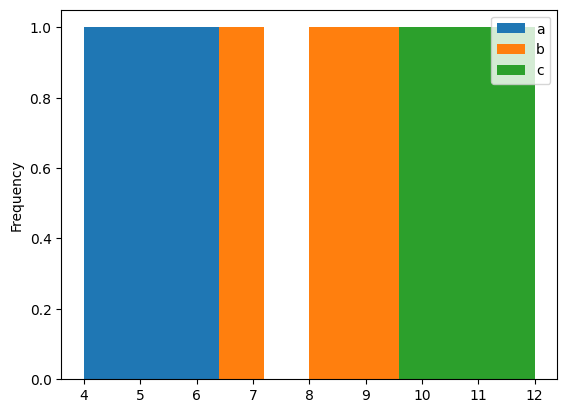

In [48]:
df.plot.hist()

<Axes: xlabel='a', ylabel='b'>

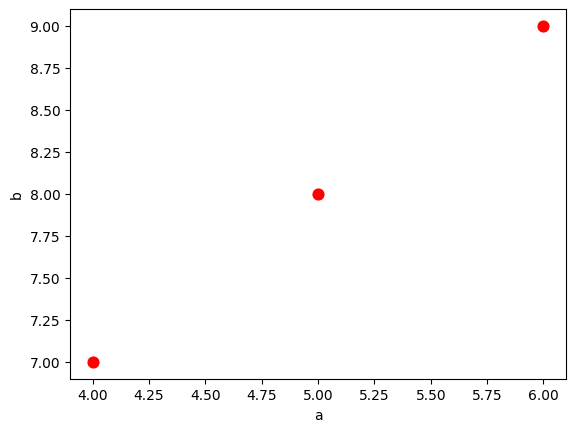

In [56]:
df.plot.scatter(x='a', y='b', s=60, c='red')

In [50]:
df

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12
